# Figure 2: Integral Feedback and Robust Perfect Adaptation

**Panel A** — Equations of a minimal integral feedback model:

$$\frac{dA}{dt} = \alpha\,(\mu - B)$$
$$\frac{dB}{dt} = \beta_1 A - \beta_2 B$$

In [43]:
"""Shared parameters, ODE models, simulation functions, and plotting helpers for Figure 2."""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp
import sys
sys.path.insert(0, '../src')
from rpa_control.style import set_style

set_style()
plt.rcParams['text.usetex'] = False

# ======================================================================
# Plotting helpers
# ======================================================================

HARD_COLOR = '#b8e6b8'   # light green for hard spring
SOFT_COLOR = "#ffe8e8"   # light pink for soft spring
SHADE_ALPHA = 0.6

def rk4_step(f, y, dt):
    k1 = f(y); k2 = f(y + 0.5*dt*k1)
    k3 = f(y + 0.5*dt*k2); k4 = f(y + dt*k3)
    return y + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

def text_panel(ax, lines, fontsize=11):
    ax.axis('off')
    ax.text(0.05, 0.95, '\n'.join(lines), transform=ax.transAxes,
            fontsize=fontsize, verticalalignment='top', family='serif', linespacing=1.6)

def clean_ax(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def shade_spring(ax, t, ctrl, hard_val, soft_val):
    """Shade background regions: hard spring vs soft spring."""
    is_hard = np.isclose(ctrl, hard_val)
    changes = np.where(np.diff(is_hard.astype(int)) != 0)[0]
    boundaries = np.concatenate([[0], changes + 1, [len(t) - 1]])
    for j in range(len(boundaries) - 1):
        i0, i1 = boundaries[j], boundaries[j + 1]
        color = HARD_COLOR if is_hard[i0] else SOFT_COLOR
        ax.axvspan(t[i0], t[i1], color=color, alpha=SHADE_ALPHA, lw=0)

def adaptive_alpha(B, Bdot, alpha_hard, alpha_soft, eq):
    """Adaptive spring strategy:
    - Hard spring when moving toward equilibrium (accelerate return)
    - Soft spring when moving away from equilibrium (reduce overshoot)
    """
    if B > eq:
        return alpha_hard if Bdot < 0 else alpha_soft
    else:
        return alpha_hard if Bdot > 0 else alpha_soft

# ======================================================================
# Shared parameters
# ======================================================================

mu = 1.0       # equilibrium setpoint
T = 10.0       # simulation horizon (shared across all panels)
dt = 0.005     # RK4 timestep for adaptive simulations

# --- Panel B: perturbation scenarios ---
PANEL_B = dict(
    alpha=1.0,
    x0=[0.0, 0.0],
    perturbations=[
        (1.0, 1.0, r'$\beta_1\!=\!1,\,\beta_2\!=\!1$'),
        (2.0, 1.0, r'$\beta_1\!=\!2,\,\beta_2\!=\!1$'),
        (0.5, 1.0, r'$\beta_1\!=\!0.5,\,\beta_2\!=\!1$'),
        (1.0, 2.0, r'$\beta_1\!=\!1,\,\beta_2\!=\!2$'),
        (1.0, 0.5, r'$\beta_1\!=\!1,\,\beta_2\!=\!0.5$'),
    ],
)

# --- Panel D: hard vs soft spring (minimal model) ---
PANEL_D = dict(
    beta1=1.0, beta2=1.0,
    alpha_hard=1.0, alpha_soft=0.2,
    x0=[0.5, 2.0],
)

# --- Panel E: adaptive switching (minimal model) ---
PANEL_E = dict(
    beta1=1.0, beta2=1.0,
    alpha_hard=50.0, alpha_soft=10.0,
    x0=[0.0, 0.0],
)

# --- Panels F/G: Calcium model ---
CALCIUM = dict(
    k0=1.0, k1=1.0, k2=20.0, R0=1.0, Vcl=0.0,
    k3_hard=5.0, k3_soft=1.0,
)
CALCIUM['x0'] = [0.0, CALCIUM['Vcl'] / CALCIUM['k2']]

# ======================================================================
# ODE right-hand sides
# ======================================================================

def minimal_rhs(y, alpha, beta1, beta2):
    A, B = y
    return np.array([alpha * (mu - B), beta1 * A - beta2 * B])

def calcium_rhs(y, k3, p=CALCIUM):
    Ca, D = y
    P = p['k0'] * (p['R0'] - Ca)
    return np.array([p['k1']*P + p['k2']*D - p['Vcl'], k3*P])

# ======================================================================
# Simulation runners (return dicts with all data needed for plotting)
# ======================================================================

def run_panel_B():
    p = PANEL_B
    t = np.linspace(0, T, 500)
    traces = []
    for beta1, beta2, label in p['perturbations']:
        sol = solve_ivp(lambda t_, y, b1=beta1, b2=beta2:
                        minimal_rhs(y, p['alpha'], b1, b2).tolist(),
                        [0, T], p['x0'], dense_output=True, max_step=0.05)
        traces.append(sol.sol(t)[1])
    return dict(t=t, traces=traces, labels=[x[2] for x in p['perturbations']])

def run_panel_D():
    p = PANEL_D
    t = np.linspace(0, T, 1000)
    results = {}
    for name, alpha in [('soft', p['alpha_soft']), ('hard', p['alpha_hard'])]:
        sol = solve_ivp(lambda t_, y, a=alpha:
                        minimal_rhs(y, a, p['beta1'], p['beta2']).tolist(),
                        [0, T], p['x0'], dense_output=True, max_step=0.05)
        results[name] = sol.sol(t)[1]
    return dict(t=t, **results)

def _run_adaptive_minimal(p):
    n_steps = int(T / dt)
    t_arr = np.linspace(0, T, n_steps + 1)
    y = np.zeros((n_steps + 1, 2)); y[0] = p['x0']
    alpha_t = np.zeros(n_steps + 1)
    for i in range(n_steps):
        A, B = y[i]
        Bdot = p['beta1'] * A - p['beta2'] * B
        ai = adaptive_alpha(B, Bdot, p['alpha_hard'], p['alpha_soft'], mu)
        alpha_t[i] = ai
        y[i+1] = rk4_step(lambda y_: minimal_rhs(y_, ai, p['beta1'], p['beta2']), y[i], dt)
    alpha_t[-1] = alpha_t[-2]
    return dict(t=t_arr, y=y, alpha=alpha_t)

def run_panel_E():
    return _run_adaptive_minimal(PANEL_E)

def _run_adaptive_calcium(cp):
    n_steps = int(T / dt)
    t_arr = np.linspace(0, T, n_steps + 1)
    y = np.zeros((n_steps + 1, 2)); y[0] = cp['x0']
    k3_t = np.zeros(n_steps + 1)
    for i in range(n_steps):
        Ca, D = y[i]
        P = cp['k0'] * (cp['R0'] - Ca)
        Ca_dot = cp['k1']*P + cp['k2']*D - cp['Vcl']
        k3i = adaptive_alpha(Ca, Ca_dot, cp['k3_hard'], cp['k3_soft'], cp['R0'])
        k3_t[i] = k3i
        y[i+1] = rk4_step(lambda y_: calcium_rhs(y_, k3i, cp), y[i], dt)
    k3_t[-1] = k3_t[-2]
    return dict(t=t_arr, y=y, k3=k3_t)

def run_panel_G():
    cp = CALCIUM
    t = np.linspace(0, T, 1000)
    fixed = {}
    for name, k3 in [('soft', cp['k3_soft']), ('hard', cp['k3_hard'])]:
        sol = solve_ivp(lambda t_, y, k=k3: calcium_rhs(y, k, cp).tolist(),
                        [0, T], cp['x0'], dense_output=True, max_step=0.05)
        fixed[name] = sol.sol(t)[0]
    adaptive = _run_adaptive_calcium(cp)
    return dict(t_fixed=t, fixed=fixed, adaptive=adaptive)

# ======================================================================
# Run all simulations
# ======================================================================
data_B = run_panel_B()
data_D = run_panel_D()
data_E = run_panel_E()
data_G = run_panel_G()

print("All simulations complete.")

All simulations complete.


**Panel B** — Fixed perturbations to b1, b2 fail to change B's steady-state:

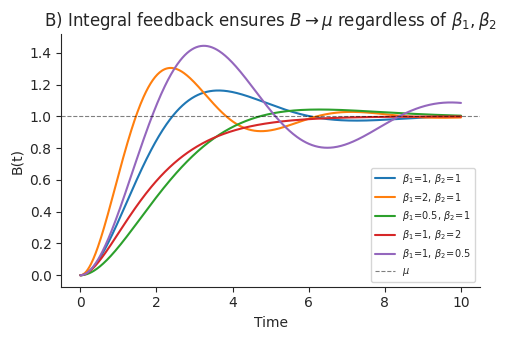

In [44]:
# Panel B: standalone plot
fig, ax = plt.subplots(figsize=(5, 3.5))
for label, B_tr in zip(data_B['labels'], data_B['traces']):
    ax.plot(data_B['t'], B_tr, lw=1.5, label=label)
ax.axhline(mu, color='black', ls='--', lw=0.8, alpha=0.5, label=r'$\mu$')
ax.set_xlabel('Time'); ax.set_ylabel('B(t)')
ax.set_title(r'B) Integral feedback ensures $B \to \mu$ regardless of $\beta_1, \beta_2$')
ax.legend(fontsize=7, loc='lower right'); clean_ax(ax)
plt.tight_layout()
fig.savefig('figure2_panelB.pdf', bbox_inches='tight')
plt.show()

**Panel C** - The integral feedback system is equivalent to a damped harmonic oscillator.

Eliminating $A$ yields a single second-order ODE:

$$\frac{d^2B}{dt^2} + \beta_2 \frac{dB}{dt} + \alpha\beta_1 B = \alpha\beta_1\mu$$

Setting $x = B - \mu$ gives the standard unforced form $\ddot{x} + \beta_2\,\dot{x} + \alpha\beta_1\,x = 0$, with:

| Physical quantity | Parameter |
|---|---|
| Mass $m$ | $1$ |
| Damping $c$ | $\beta_2$ |
| **Spring constant $k$** | $\alpha\beta_1$ |

See the full derivation in the SI.

**Panel D** — The two extreme spring states:

![Hard and soft spring diagram](hard_soft_spring.png)

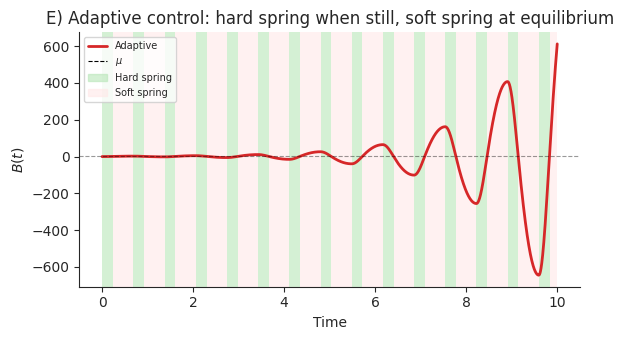

In [45]:
# Panel E: standalone plot — background shading for hard/soft spring
fig, ax = plt.subplots(figsize=(6, 3.5))
shade_spring(ax, data_E['t'], data_E['alpha'],
             PANEL_E['alpha_hard'], PANEL_E['alpha_soft'])
ax.plot(data_E['t'], data_E['y'][:, 1], lw=2, color='C3', label='Adaptive switching')
ax.axhline(mu, color='black', ls='--', lw=0.8, alpha=0.4, label=r'$\mu$')
ax.set_ylabel('$B(t)$'); ax.set_xlabel('Time')
ax.set_title(r'E) Adaptive control: hard spring when still, soft spring at equilibrium')
ax.legend(handles=[
    plt.Line2D([0],[0], color='C3', lw=2, label='Adaptive'),
    plt.Line2D([0],[0], color='black', ls='--', lw=0.8, label=r'$\mu$'),
    mpatches.Patch(color=HARD_COLOR, alpha=SHADE_ALPHA, label='Hard spring'),
    mpatches.Patch(color=SOFT_COLOR, alpha=SHADE_ALPHA, label='Soft spring'),
], fontsize=7, loc='upper left')
clean_ax(ax); plt.tight_layout()
fig.savefig('figure2_panelE.pdf', bbox_inches='tight')
plt.show()

**Panel F** — The Calcium signaling model is also equivalent to a damped harmonic oscillator.

The 3-variable Calcium model:

$$P = k_0(R_0 - Ca), \qquad \frac{dCa}{dt} = k_1 P + k_2 D - V_{cl}, \qquad \frac{dD}{dt} = k_3 P$$

reduces to a single second-order ODE:

$$\frac{d^2Ca}{dt^2} + k_1 k_0 \frac{dCa}{dt} + k_2 k_3 k_0\, Ca = k_2 k_3 k_0\, R_0$$

Setting $x = Ca - R_0$ gives the unforced form $\ddot{x} + k_1 k_0\,\dot{x} + k_2 k_3 k_0\,x = 0$, with:

| Physical quantity | Parameter |
|---|---|
| Mass $m$ | $1$ |
| Damping $c$ | $k_1 k_0$ |
| **Spring constant $k$** | $k_2 k_3 k_0$ |

See the full derivation in the SI.

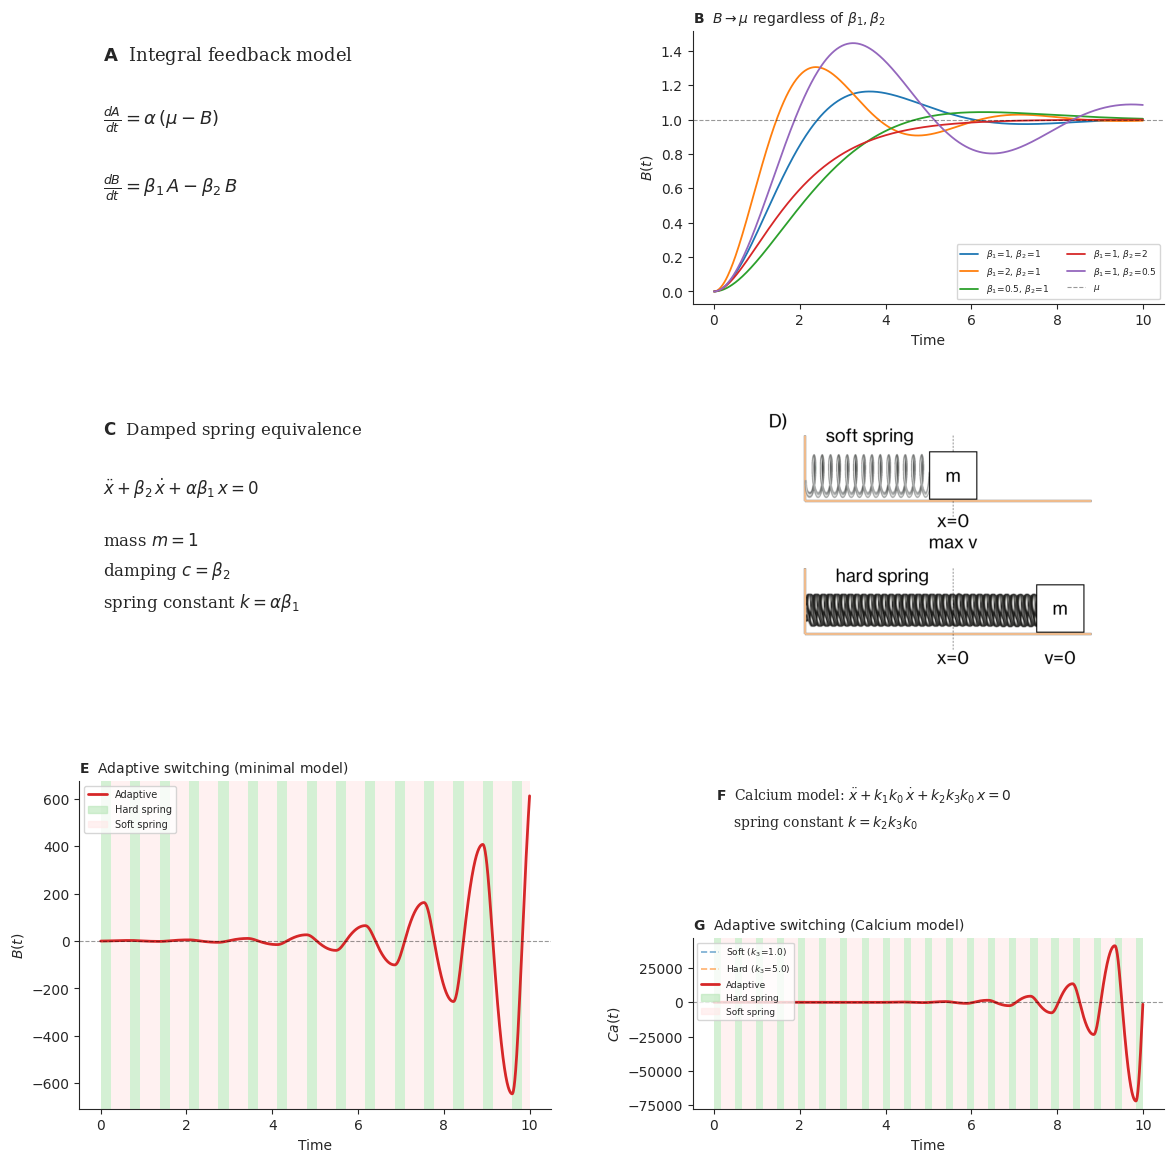

Saved figure2_composite.pdf


In [46]:
# ======================================================================
# COMPOSITE FIGURE — uses shared data, background shading for E/G
# ======================================================================
fig = plt.figure(figsize=(14, 14))
gs = gridspec.GridSpec(3, 2, figure=fig,
                       height_ratios=[1, 1, 1.2],
                       hspace=0.35, wspace=0.3)

# --- Panel A: equations ---
ax_A = fig.add_subplot(gs[0, 0])
text_panel(ax_A, [
    r'$\mathbf{A}$  Integral feedback model',
    '', r'$\frac{dA}{dt} = \alpha\,(\mu - B)$',
    '', r'$\frac{dB}{dt} = \beta_1\, A - \beta_2\, B$',
], fontsize=13)

# --- Panel B: parameter perturbations ---
ax_B = fig.add_subplot(gs[0, 1])
for label, B_tr in zip(data_B['labels'], data_B['traces']):
    ax_B.plot(data_B['t'], B_tr, lw=1.3, label=label)
ax_B.axhline(mu, color='black', ls='--', lw=0.8, alpha=0.4, label=r'$\mu$')
ax_B.set_ylabel('$B(t)$'); ax_B.set_xlabel('Time')
ax_B.set_title(r'$\mathbf{B}$  $B \to \mu$ regardless of $\beta_1, \beta_2$',
               fontsize=10, loc='left')
ax_B.legend(fontsize=6.5, loc='lower right', ncol=2); clean_ax(ax_B)

# --- Panel C: spring equivalence ---
ax_C = fig.add_subplot(gs[1, 0])
text_panel(ax_C, [
    r'$\mathbf{C}$  Damped spring equivalence',
    '', r'$\ddot{x} + \beta_2\,\dot{x} + \alpha\beta_1\,x = 0$',
    '', r'mass $m = 1$', r'damping $c = \beta_2$',
    r'spring constant $k = \alpha\beta_1$',
], fontsize=12)

# --- Panel D: hard/soft spring diagram ---
ax_D = fig.add_subplot(gs[1, 1])
img_D = plt.imread('hard_soft_spring.png')
ax_D.imshow(img_D)
ax_D.axis('off')

# --- Panel E: adaptive switching (minimal model) with shading ---
ax_E = fig.add_subplot(gs[2, 0])
shade_spring(ax_E, data_E['t'], data_E['alpha'],
             PANEL_E['alpha_hard'], PANEL_E['alpha_soft'])
ax_E.plot(data_E['t'], data_E['y'][:, 1], lw=2, color='C3')
ax_E.axhline(mu, color='black', ls='--', lw=0.8, alpha=0.4)
ax_E.set_ylabel('$B(t)$'); ax_E.set_xlabel('Time')
ax_E.set_title(r'$\mathbf{E}$  Adaptive switching (minimal model)',
               fontsize=10, loc='left')
ax_E.legend(handles=[
    plt.Line2D([0],[0], color='C3', lw=2, label='Adaptive'),
    mpatches.Patch(color=HARD_COLOR, alpha=SHADE_ALPHA, label='Hard spring'),
    mpatches.Patch(color=SOFT_COLOR, alpha=SHADE_ALPHA, label='Soft spring'),
], fontsize=7, loc='upper left')
clean_ax(ax_E)

# --- Panel F + G combined in right column ---
gs_right = gs[2, 1].subgridspec(2, 1, height_ratios=[0.6, 1], hspace=0.4)

ax_F = fig.add_subplot(gs_right[0])
text_panel(ax_F, [
    r'$\mathbf{F}$  Calcium model: $\ddot{x} + k_1 k_0\,\dot{x} + k_2 k_3 k_0\,x = 0$',
    r'    spring constant $k = k_2 k_3 k_0$',
], fontsize=10)

dG = data_G
ax_G = fig.add_subplot(gs_right[1])
shade_spring(ax_G, dG['adaptive']['t'], dG['adaptive']['k3'],
             CALCIUM['k3_hard'], CALCIUM['k3_soft'])
# ax_G.plot(dG['t_fixed'], dG['fixed']['soft'], lw=1.2, ls='--', alpha=0.6, color='C0')
# ax_G.plot(dG['t_fixed'], dG['fixed']['hard'], lw=1.2, ls='--', alpha=0.6, color='C1')
ax_G.plot(dG['adaptive']['t'], dG['adaptive']['y'][:, 0], lw=2, color='C3')
ax_G.axhline(CALCIUM['R0'], color='black', ls='--', lw=0.8, alpha=0.4)
ax_G.set_ylabel('$Ca(t)$'); ax_G.set_xlabel('Time')
ax_G.set_title(r'$\mathbf{G}$  Adaptive switching (Calcium model)',
               fontsize=10, loc='left')
ax_G.legend(handles=[
    plt.Line2D([0],[0], color='C0', ls='--', lw=1.2, alpha=0.6, label=rf'Soft ($k_3\!=\!{CALCIUM["k3_soft"]}$)'),
    plt.Line2D([0],[0], color='C1', ls='--', lw=1.2, alpha=0.6, label=rf'Hard ($k_3\!=\!{CALCIUM["k3_hard"]}$)'),
    plt.Line2D([0],[0], color='C3', lw=2, label='Adaptive'),
    mpatches.Patch(color=HARD_COLOR, alpha=SHADE_ALPHA, label='Hard spring'),
    mpatches.Patch(color=SOFT_COLOR, alpha=SHADE_ALPHA, label='Soft spring'),
], fontsize=6.5, loc='upper left')
clean_ax(ax_G)

fig.savefig('figure2_composite.pdf', bbox_inches='tight')
plt.show()
print("Saved figure2_composite.pdf")

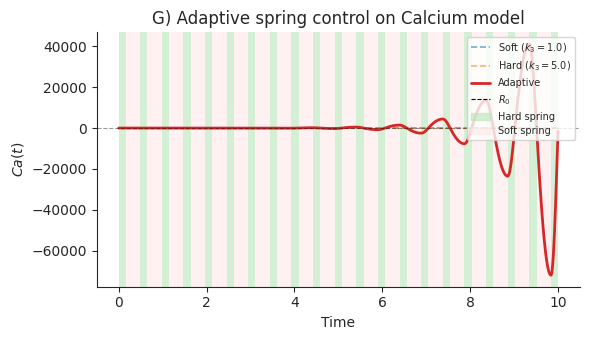

In [47]:
# Panel G: standalone plot — background shading for hard/soft spring
dG = data_G
fig, ax = plt.subplots(figsize=(6, 3.5))
shade_spring(ax, dG['adaptive']['t'], dG['adaptive']['k3'],
             CALCIUM['k3_hard'], CALCIUM['k3_soft'])
ax.plot(dG['t_fixed'], dG['fixed']['soft'], lw=1.2, ls='--', alpha=0.6, color='C0',
        label=rf'Soft ($k_3={CALCIUM["k3_soft"]}$)')
ax.plot(dG['t_fixed'], dG['fixed']['hard'], lw=1.2, ls='--', alpha=0.6, color='C1',
        label=rf'Hard ($k_3={CALCIUM["k3_hard"]}$)')
ax.plot(dG['adaptive']['t'], dG['adaptive']['y'][:, 0], lw=2, color='C3', label='Adaptive')
ax.axhline(CALCIUM['R0'], color='black', ls='--', lw=0.8, alpha=0.4, label=r'$R_0$')
ax.set_ylabel('$Ca(t)$'); ax.set_xlabel('Time')
ax.set_title(r'G) Adaptive spring control on Calcium model')
ax.legend(handles=[
    plt.Line2D([0],[0], color='C0', ls='--', lw=1.2, alpha=0.6, label=rf'Soft ($k_3={CALCIUM["k3_soft"]}$)'),
    plt.Line2D([0],[0], color='C1', ls='--', lw=1.2, alpha=0.6, label=rf'Hard ($k_3={CALCIUM["k3_hard"]}$)'),
    plt.Line2D([0],[0], color='C3', lw=2, label='Adaptive'),
    plt.Line2D([0],[0], color='black', ls='--', lw=0.8, label=r'$R_0$'),
    mpatches.Patch(color=HARD_COLOR, alpha=SHADE_ALPHA, label='Hard spring'),
    mpatches.Patch(color=SOFT_COLOR, alpha=SHADE_ALPHA, label='Soft spring'),
], fontsize=7, loc='upper right')
clean_ax(ax); plt.tight_layout()
fig.savefig('figure2_panelG.pdf', bbox_inches='tight')
plt.show()

# Supplementary:

### SI: Derivation — Integral Feedback as a Damped Mass-Spring System

**Goal:** Transform the coupled first-order ODE system into a single second-order ODE equivalent to a damped harmonic oscillator.

**Given System:**

$$\frac{dA}{dt} = \alpha(\mu - B) \tag{1}$$

$$\frac{dB}{dt} = \beta_1 A - \beta_2 B \tag{2}$$

**Step 1:** Differentiate Eq. 2 with respect to $t$:

$$\frac{d^2B}{dt^2} = \beta_1 \frac{dA}{dt} - \beta_2 \frac{dB}{dt}$$

**Step 2:** Substitute $\frac{dA}{dt}$ from Eq. 1:

$$\frac{d^2B}{dt^2} = \beta_1 \alpha(\mu - B) - \beta_2 \frac{dB}{dt}$$

**Step 3:** Rearrange into standard second-order form:

$$\frac{d^2B}{dt^2} + \beta_2 \frac{dB}{dt} + \alpha\beta_1 B = \alpha\beta_1\mu$$

**Step 4:** Map to the damped mass-spring equation $m\ddot{x} + c\dot{x} + kx = F_{\text{ext}}$:

| Physical quantity | Our system |
|---|---|
| Mass ($m$) | $1$ |
| Damping coefficient ($c$) | $\beta_2$ |
| Spring constant ($k$) | $\alpha\beta_1$ |
| External force ($F_{\text{ext}}$) | $\alpha\beta_1\mu$ |

**Step 5:** Define displacement from equilibrium $x(t) = B(t) - \mu$. Since $\mu$ is constant, $\dot{x} = \dot{B}$ and $\ddot{x} = \ddot{B}$. Substituting $B = x + \mu$:

$$\ddot{x} + \beta_2\,\dot{x} + \alpha\beta_1(x + \mu) = \alpha\beta_1\mu$$

$$\boxed{\ddot{x} + \beta_2\,\dot{x} + \alpha\beta_1\,x = 0}$$

This confirms the system behaves as a damped spring with spring constant $k = \alpha\beta_1$, oscillating around the equilibrium $B_{\text{eq}} = \mu$.

### SI: Derivation — Calcium Model as a Damped Mass-Spring System

**Goal:** Reduce the 3-variable Calcium system ($P$, $Ca$, $D$) into a single second-order ODE in $Ca$.

**Given System:**

$$P = k_0(R_0 - Ca) \tag{1}$$

$$\frac{dCa}{dt} = k_1 P + k_2 D - V_{cl} \tag{2}$$

$$\frac{dD}{dt} = k_3 P \tag{3}$$

**Step 1:** Substitute $P$ from Eq. 1 into Eqs. 2 and 3:

$$\frac{dCa}{dt} = k_1 k_0(R_0 - Ca) + k_2 D - V_{cl}$$

$$\frac{dD}{dt} = k_3 k_0(R_0 - Ca)$$

**Step 2:** Differentiate the $\frac{dCa}{dt}$ equation with respect to $t$ (all $k$'s, $R_0$, $V_{cl}$ constant):

$$\frac{d^2Ca}{dt^2} = -k_1 k_0 \frac{dCa}{dt} + k_2 \frac{dD}{dt}$$

**Step 3:** Substitute $\frac{dD}{dt}$ from Step 1:

$$\frac{d^2Ca}{dt^2} = -k_1 k_0 \frac{dCa}{dt} + k_2 k_3 k_0(R_0 - Ca)$$

**Step 4:** Rearrange into standard second-order form:

$$\frac{d^2Ca}{dt^2} + k_1 k_0 \frac{dCa}{dt} + k_2 k_3 k_0\, Ca = k_2 k_3 k_0\, R_0$$

**Step 5:** Map to the damped mass-spring equation $m\ddot{x} + c\dot{x} + kx = F_{\text{ext}}$:

| Physical quantity | Our system |
|---|---|
| Mass ($m$) | $1$ |
| Damping coefficient ($c$) | $k_1 k_0$ |
| Spring constant ($k$) | $k_2 k_3 k_0$ |
| External force ($F_{\text{ext}}$) | $k_2 k_3 k_0\, R_0$ |

**Step 6:** At steady state, $\frac{dD}{dt} = 0$ requires $Ca = R_0$. Define $x(t) = Ca(t) - R_0$:

$$\ddot{x} + k_1 k_0\,\dot{x} + k_2 k_3 k_0(x + R_0) = k_2 k_3 k_0\, R_0$$

$$\boxed{\ddot{x} + k_1 k_0\,\dot{x} + k_2 k_3 k_0\,x = 0}$$

This confirms the Calcium dynamics behave as a damped spring with spring constant $k = k_2 k_3 k_0$, oscillating around $Ca_{\text{eq}} = R_0$.